## Notebook 2: Feature Relationship Analysis and Dimensionality Assessment

### Objective

The objective of this notebook is to examine the relationships among the selected socioeconomic indicators used to assess neighbourhood vulnerability in Toronto.

Following the data preparation process completed in Notebook 1, this analysis focuses on understanding the statistical properties of the selected variables, identifying potential feature redundancy, and evaluating the degree of association between indicators.

The notebook includes:

- Descriptive statistical analysis
- Correlation analysis and visualization
- Identification of strongly related features
- Feature standardization using Z-score normalization
- Principal Component Analysis (PCA) for dimensionality assessment

These analyses provide insight into the structure of the dataset and help determine whether the selected indicators capture distinct aspects of socioeconomic vulnerability or represent overlapping dimensions of disadvantage.

The findings will support the construction of vulnerability measures and neighbourhood risk classifications in Notebook 3.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)

### Load Toronto Neighbourhood (Census) Dataset

In [2]:
DATA_DIR = Path(r"C:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\data")

raw = pd.read_csv(DATA_DIR / "neighbourhood-profiles-2016-140-model.csv")

raw["Characteristic"] = raw["Characteristic"].str.strip()

print(raw.shape)

(2383, 146)


### Select Socioeconomic Vulnerability Indicators

The following indicators were selected based on the exploratory data analysis:

- Low-income prevalence
- Immigrant population
- Visible minority population
- Renters
- No diploma
- Bachelor's degree
- Core housing need
- Unaffordable housing
- Participation rate
- Employment rate
- Unemployment rate
- Lone-parent families

In [3]:
selected_rows = raw.loc[[
    1130,  # LIM_AT
    1152,  # Immigrants
    1336,  # Visible Minority Population
    1629,  # Renters
    1703,  # No Diploma
    1710,  # Bachelor's Degree
    1682,  # Households in Core Housing Need
    1688,  # Unaffordable Housing
    1888,  # Participation Rate
    1889,  # Employment Rate
    1890,  # Unemployment Rate
    102    # Lone Parent Families
]]

selected_rows.shape

(12, 146)

### Create Neighbourhood-Level Dataset

In [4]:
data_only = selected_rows.iloc[:, 5:]

data_only.shape

(12, 141)

In [5]:
#Transpose
selected_df = data_only.T

selected_df.shape

(141, 12)

In [6]:
#Rename Variables 
selected_df.columns = [

    "LIM_AT",
    "Immigrants",
    "Visible_Minority",
    "Renters",
    "No_Diploma",
    "Bachelors_Degree",
    "Core_Housing_Need",
    "Unaffordable_Housing",
    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",
    "Lone_Parent_Families"
]

In [7]:
#Remove City of Toronto aggreagate
selected_df = selected_df.drop("City of Toronto")

selected_df.shape

(140, 12)

In [8]:
#Convert object into Integer
selected_df = selected_df.replace(",", "", regex=True)

selected_df = selected_df.apply(
    pd.to_numeric,
    errors="coerce")

### Validate Final Dataset

In [9]:
selected_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, Agincourt North to Yorkdale-Glen Park
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LIM_AT                140 non-null    float64
 1   Immigrants            140 non-null    int64  
 2   Visible_Minority      140 non-null    int64  
 3   Renters               140 non-null    int64  
 4   No_Diploma            140 non-null    int64  
 5   Bachelors_Degree      140 non-null    int64  
 6   Core_Housing_Need     140 non-null    int64  
 7   Unaffordable_Housing  140 non-null    float64
 8   Participation_Rate    140 non-null    float64
 9   Employment_Rate       140 non-null    float64
 10  Unemployment_Rate     140 non-null    float64
 11  Lone_Parent_Families  140 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 14.2+ KB


In [10]:
selected_df.isnull().sum()

LIM_AT                  0
Immigrants              0
Visible_Minority        0
Renters                 0
No_Diploma              0
Bachelors_Degree        0
Core_Housing_Need       0
Unaffordable_Housing    0
Participation_Rate      0
Employment_Rate         0
Unemployment_Rate       0
Lone_Parent_Families    0
dtype: int64

In [11]:
selected_df.head()

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,21.3,19995,26365,1720,6550,4380,2220,34.7,55.4,50.0,9.8,1650
Agincourt South-Malvern West,22.6,15095,20155,2250,4035,4210,1795,38.2,59.0,53.2,9.8,1360
Alderwood,8.2,3970,2490,950,2005,1660,540,21.7,66.5,62.4,6.1,670
Annex,18.3,8270,7270,9870,1585,9135,2420,40.4,70.6,65.8,6.7,895
Banbury-Don Mills,13.7,13195,12700,4735,2295,6500,2115,33.4,59.9,55.6,7.2,1255


In [12]:
selected_df.shape


(140, 12)

In [13]:
selected_df.isnull().sum()

LIM_AT                  0
Immigrants              0
Visible_Minority        0
Renters                 0
No_Diploma              0
Bachelors_Degree        0
Core_Housing_Need       0
Unaffordable_Housing    0
Participation_Rate      0
Employment_Rate         0
Unemployment_Rate       0
Lone_Parent_Families    0
dtype: int64

# Feature Relationship Analysis

To assess whether the selected socioeconomic indicators are related, a
correlation analysis is performed using the final neighbourhood-level
modelling dataset.

The objectives of this analysis are to:

- Identify relationships between indicators
- Detect highly correlated variables
- Assess potential multicollinearity
- Support future dimensionality reduction decisions
- Inform vulnerability score construction

Pearson correlation coefficients are used to measure linear relationships
between variables.

### Descriptive Statistics

Summary statistics are examined to understand the distribution,
central tendency, and variability of each selected indicator.

In [14]:
selected_df.describe().round(2)

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
count,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00
mean,19.51,9042.89,9899.04,3755.68,2694.89,3819.00,1720.14,35.07,64.55,59.27,8.30,1090.39
std,7.89,6141.42,8355.39,3008.98,1880.90,3046.74,1002.88,6.94,6.11,6.52,1.90,660.31
min,4.50,1795.00,1100.00,280.00,460.00,445.00,115.00,17.50,52.20,47.30,4.50,220.00
25%,14.10,4621.25,3633.75,1946.25,1423.75,2053.75,967.50,31.08,59.88,54.68,6.90,640.00
50%,18.55,7502.50,7122.50,3232.50,2157.50,3257.50,1432.50,35.60,63.60,58.55,8.20,870.00
75%,23.95,11327.50,12505.00,4338.75,3457.50,4385.00,2287.50,38.52,69.12,64.30,9.62,1365.00
max,45.50,31040.00,40510.00,23930.00,9560.00,27280.00,5335.00,56.50,86.60,82.70,14.60,3460.00


### Correlation Matrix

A Pearson correlation matrix is generated to evaluate relationships
between the selected socioeconomic indicators.

Correlation values range from:

- -1 : Perfect negative relationship
- 0  : No relationship
- +1 : Perfect positive relationship

Strong correlations may indicate overlapping information and potential
multicollinearity.

In [15]:
corr_matrix = selected_df.corr()

corr_matrix.round(2)

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
LIM_AT,1.00,0.35,0.41,0.33,0.29,-0.01,0.55,0.78,-0.39,-0.47,0.73,0.34
Immigrants,0.35,1.00,0.97,0.46,0.77,0.52,0.81,0.36,-0.35,-0.38,0.41,0.88
Visible_Minority,0.41,0.97,1.00,0.40,0.77,0.45,0.76,0.36,-0.38,-0.42,0.49,0.86
Renters,0.33,0.46,0.40,1.00,0.16,0.82,0.74,0.52,0.35,0.31,-0.00,0.37
No_Diploma,0.29,0.77,0.77,0.16,1.00,0.05,0.67,0.12,-0.44,-0.46,0.47,0.90
Bachelors_Degree,-0.01,0.52,0.45,0.82,0.05,1.00,0.51,0.26,0.37,0.37,-0.25,0.28
Core_Housing_Need,0.55,0.81,0.76,0.74,0.67,0.51,1.00,0.55,-0.12,-0.17,0.40,0.81
Unaffordable_Housing,0.78,0.36,0.36,0.52,0.12,0.26,0.55,1.00,-0.06,-0.13,0.40,0.21
Participation_Rate,-0.39,-0.35,-0.38,0.35,-0.44,0.37,-0.12,-0.06,1.00,0.99,-0.67,-0.37
Employment_Rate,-0.47,-0.38,-0.42,0.31,-0.46,0.37,-0.17,-0.13,0.99,1.00,-0.77,-0.40


### Correlation Heatmap

The correlation matrix is visualized using a heatmap to facilitate
identification of strong positive and negative relationships.

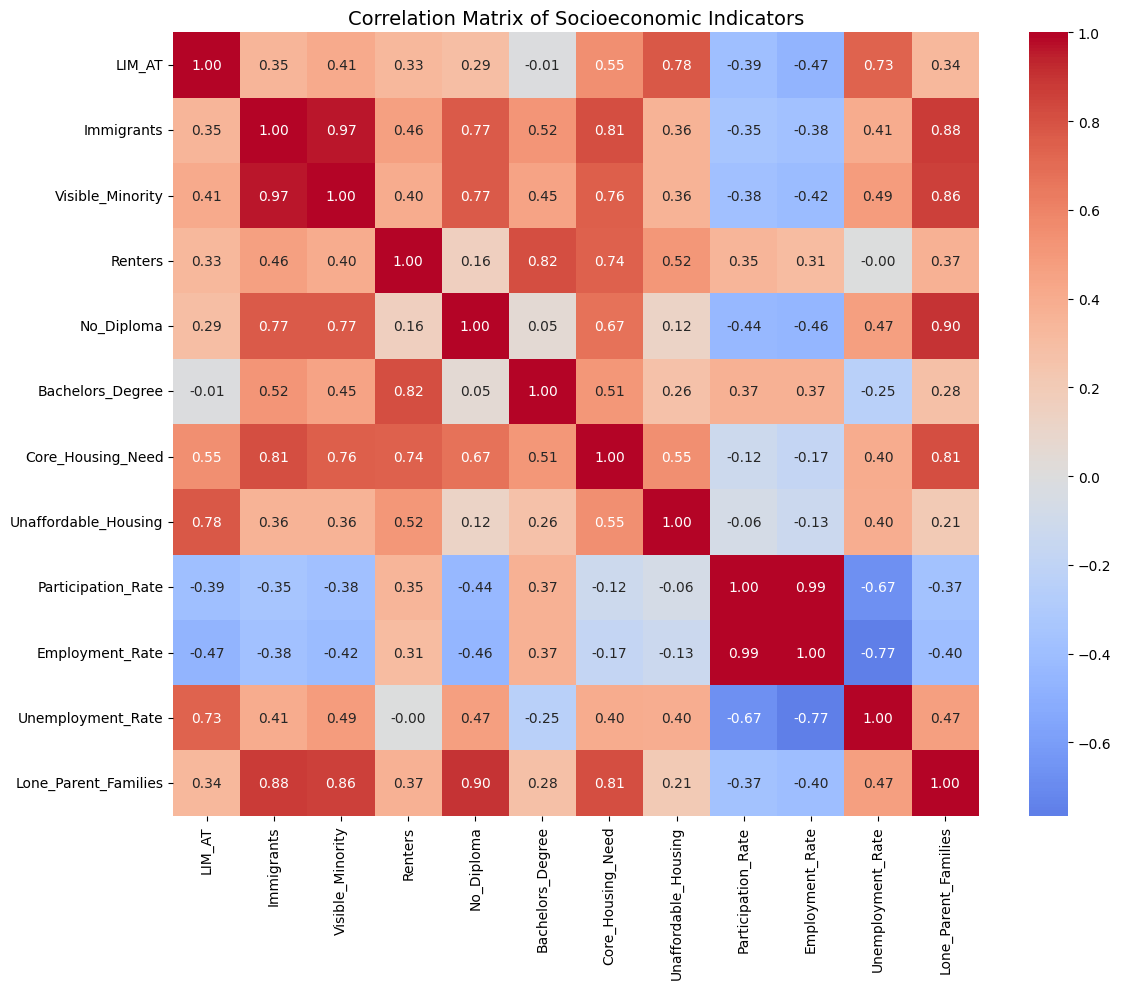

In [16]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f")

plt.title("Correlation Matrix of Socioeconomic Indicators", fontsize=14)

plt.tight_layout()
plt.show()

### Key Findings

Several strong relationships were observed among the selected socioeconomic indicators.

The strongest positive correlation was found between Participation Rate and Employment Rate (r = 0.99), indicating that neighbourhoods with higher labour force participation also tend to have higher employment levels.

Strong associations were also observed between:

- Immigrants and Visible Minority Population (r = 0.97)
- No Diploma and Lone Parent Families (r = 0.90)
- Immigrants and Lone Parent Families (r = 0.88)
- Renters and Bachelor's Degree (r = 0.82)
- Immigrants and Core Housing Need (r = 0.81)

These findings suggest the presence of overlapping socioeconomic characteristics and potential multicollinearity among some indicators.

The results support further investigation through clustering and dimensionality reduction techniques in subsequent analyses.

In [17]:
corr_matrix.abs().unstack().sort_values(ascending=False)

LIM_AT              LIM_AT                1.000000
Immigrants          Immigrants            1.000000
Unemployment_Rate   Unemployment_Rate     1.000000
Employment_Rate     Employment_Rate       1.000000
Participation_Rate  Participation_Rate    1.000000
                                            ...   
No_Diploma          Bachelors_Degree      0.052908
Bachelors_Degree    LIM_AT                0.013316
LIM_AT              Bachelors_Degree      0.013316
Unemployment_Rate   Renters               0.002591
Renters             Unemployment_Rate     0.002591
Length: 144, dtype: float64

In [18]:
strong_corr = (
    corr_matrix.abs()
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .unstack()
    .sort_values(ascending=False))

strong_corr.head(20)

Participation_Rate    Employment_Rate         0.990743
Employment_Rate       Participation_Rate      0.990743
Immigrants            Visible_Minority        0.965324
Visible_Minority      Immigrants              0.965324
Lone_Parent_Families  No_Diploma              0.897220
No_Diploma            Lone_Parent_Families    0.897220
Immigrants            Lone_Parent_Families    0.878987
Lone_Parent_Families  Immigrants              0.878987
Visible_Minority      Lone_Parent_Families    0.855924
Lone_Parent_Families  Visible_Minority        0.855924
Bachelors_Degree      Renters                 0.815097
Renters               Bachelors_Degree        0.815097
Immigrants            Core_Housing_Need       0.811640
Core_Housing_Need     Immigrants              0.811640
                      Lone_Parent_Families    0.809534
Lone_Parent_Families  Core_Housing_Need       0.809534
LIM_AT                Unaffordable_Housing    0.775049
Unaffordable_Housing  LIM_AT                  0.775049
No_Diploma

## Feature Standardization

The selected indicators are measured using different units and scales. Standardization is applied to ensure that each variable contributes equally to subsequent risk scoring and clustering analyses.

A z-score transformation is used, resulting in variables with a mean of 0 and a standard deviation of 1.

In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(selected_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=selected_df.columns,
    index=selected_df.index)

scaled_df.head()

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,0.227208,1.789721,1.977775,-0.678964,2.056964,0.184792,0.500212,-0.053820,-1.502679,-1.428182,0.791877,0.850533
Agincourt South-Malvern West,0.392549,0.988995,1.231874,-0.502192,0.715039,0.128795,0.074910,0.452355,-0.911323,-0.935288,0.791877,0.409769
Alderwood,-1.438922,-0.828979,-0.889921,-0.935783,-0.368105,-0.711170,-1.180981,-1.933896,0.320670,0.481782,-1.166081,-0.638944
Annex,-0.154349,-0.126301,-0.315781,2.039321,-0.592204,1.751080,0.700354,0.770521,0.994160,1.005481,-0.848574,-0.296973
Banbury-Don Mills,-0.739402,0.678510,0.336432,0.326635,-0.213370,0.883116,0.395138,-0.241827,-0.763484,-0.565618,-0.583985,0.250182


In [20]:
scaled_df.describe().round(2)

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
count,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.91,-1.18,-1.06,-1.16,-1.19,-1.11,-1.61,-2.54,-2.03,-1.84,-2.01,-1.32
25%,-0.69,-0.72,-0.75,-0.60,-0.68,-0.58,-0.75,-0.58,-0.77,-0.71,-0.74,-0.68
50%,-0.12,-0.25,-0.33,-0.17,-0.29,-0.18,-0.29,0.08,-0.16,-0.11,-0.05,-0.33
75%,0.56,0.37,0.31,0.19,0.41,0.19,0.57,0.50,0.75,0.77,0.70,0.42
max,3.31,3.59,3.68,6.73,3.66,7.73,3.62,3.10,3.62,3.61,3.33,3.60


In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(selected_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=selected_df.columns,
    index=selected_df.index)

scaled_df.head()

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,0.227208,1.789721,1.977775,-0.678964,2.056964,0.184792,0.500212,-0.053820,-1.502679,-1.428182,0.791877,0.850533
Agincourt South-Malvern West,0.392549,0.988995,1.231874,-0.502192,0.715039,0.128795,0.074910,0.452355,-0.911323,-0.935288,0.791877,0.409769
Alderwood,-1.438922,-0.828979,-0.889921,-0.935783,-0.368105,-0.711170,-1.180981,-1.933896,0.320670,0.481782,-1.166081,-0.638944
Annex,-0.154349,-0.126301,-0.315781,2.039321,-0.592204,1.751080,0.700354,0.770521,0.994160,1.005481,-0.848574,-0.296973
Banbury-Don Mills,-0.739402,0.678510,0.336432,0.326635,-0.213370,0.883116,0.395138,-0.241827,-0.763484,-0.565618,-0.583985,0.250182


In [22]:
scaled_df.describe().round(2)


,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
count,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00,140.00
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.91,-1.18,-1.06,-1.16,-1.19,-1.11,-1.61,-2.54,-2.03,-1.84,-2.01,-1.32
25%,-0.69,-0.72,-0.75,-0.60,-0.68,-0.58,-0.75,-0.58,-0.77,-0.71,-0.74,-0.68
50%,-0.12,-0.25,-0.33,-0.17,-0.29,-0.18,-0.29,0.08,-0.16,-0.11,-0.05,-0.33
75%,0.56,0.37,0.31,0.19,0.41,0.19,0.57,0.50,0.75,0.77,0.70,0.42
max,3.31,3.59,3.68,6.73,3.66,7.73,3.62,3.10,3.62,3.61,3.33,3.60


## Standardization Results

The standardized dataset shows that all variables have means close to 0 and standard deviations close to 1

This confirms that the z-score transformation was successfully applied and that variables measured on different scales are now directly comparable.

The standardized dataset will be used for vulnerability score construction and K-Means clustering in the following sections.

## Principal Component Analysis (PCA)

PCA is used to evaluate the dimensionality of the selected socioeconomic indicators.

Because several indicators exhibit strong correlations, PCA helps identify whether a smaller number of underlying components can explain most of the variation in the dataset.

The analysis provides insight into feature redundancy and supports the interpretation of socioeconomic vulnerability patterns across Toronto neighbourhoods.

In [23]:
from sklearn.decomposition import PCA

In [24]:
pca = PCA()

pca.fit(scaled_df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [25]:
explained_variance = pd.DataFrame({
    "Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Variance": pca.explained_variance_ratio_,
    "Cumulative_Variance": pca.explained_variance_ratio_.cumsum()})

explained_variance.round(4)

,Component,Explained_Variance,Cumulative_Variance
0,1,0.4919,0.4919
1,2,0.2589,0.7508
2,3,0.1351,0.8858
3,4,0.0466,0.9324
4,5,0.0258,0.9582
5,6,0.0189,0.9771
6,7,0.0084,0.9855
7,8,0.0064,0.9919
8,9,0.0042,0.9962
9,10,0.0028,0.9989


### PCA Interpretation

PCA was conducted to assess whether the selected indicators contained redundant information.

The first principal component explained 49.2% of the total variance, while the first three components collectively explained approximately 88.6% of the variance in the dataset.

These findings indicate that a relatively small number of underlying dimensions capture most of the socioeconomic variation across Toronto neighbourhoods.

The results support the presence of strong relationships among several indicators and justify the use of dimensionality reduction techniques when constructing vulnerability measures.

### Scree Plot

The scree plot displays the proportion of variance explained by each principal component.

Components explaining the largest amount of variance are considered the most informative.

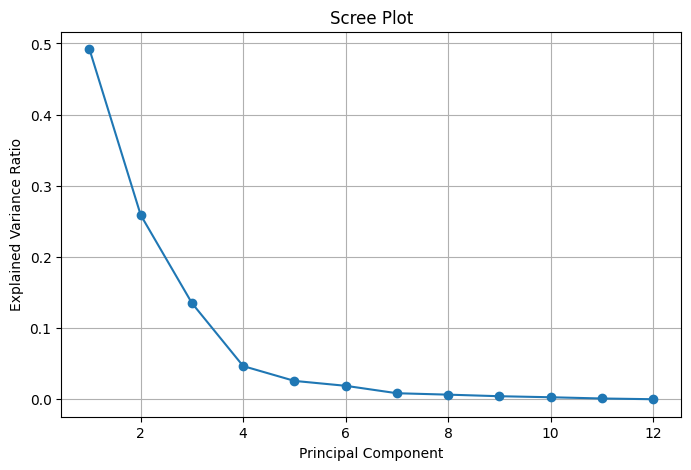

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

### PCA and Scree Plot Interpretation

PCA was performed to evaluate potential redundancy among the selected socioeconomic indicators.

The first principal component explained approximately 49.2% of the total variance, while the first three components collectively explained 88.6% of the variance in the dataset.

The scree plot exhibited a clear elbow after the third component, indicating diminishing returns from additional components.

These findings suggest that much of the socioeconomic variation across Toronto neighbourhoods can be represented by a smaller number of underlying dimensions. The results support the presence of strong relationships among several indicators and provide evidence of feature redundancy.

Despite this, all variables were retained for subsequent vulnerability analysis to preserve interpretability and policy relevance.

## Conclusion

This notebook examined the statistical relationships among the selected 12 socioeconomic indicators representing housing, education, labour market participation, demographic composition, and family structure across Toronto neighbourhoods.

Descriptive statistics revealed substantial variation among neighbourhoods for several indicators, highlighting differences in socioeconomic conditions throughout the city of Toronto.

Correlation analysis identified a number of strong positive and negative relationships between variables. In particular, indicators such as immigrant population, visible minority population, labour force participation, employment, educational attainment, and family structure exhibited substantial associations, suggesting the presence of overlapping socioeconomic patterns.

To address differences in measurement scales, all indicators were standardized using Z-score normalization. This transformation ensured that each variable contributed equally to subsequent analyses.

PCA demonstrated that the first 3 principal components explained approximately 88.6% of the total variance within the dataset. These results indicate that a relatively small number of latent dimensions capture much of the variation observed across neighbourhoods, providing evidence of feature redundancy and shared socioeconomic characteristics.

Despite the observed correlations, all selected indicators were retained to preserve interpretability and maintain alignment with the study's conceptual framework of neighbourhood vulnerability.

The standardized dataset produced in this notebook provides the foundation for Notebook 3, where vulnerability scores, risk classifications, and clustering techniques will be applied to identify and compare socioeconomically vulnerable neighbourhoods across Toronto.